In [63]:
import numpy as np
import pandas as pd
eps = 1e-10

In [64]:
y_names=["lpatent_count", "lno_patent_entities", "lcit2_wt2", "lpatent_count_top10p", "lgeneral", "lorig"]

In [66]:
# Load data
data ={}
for y in y_names:
    data[y]=pd.read_excel("data/attgt_"+y+".xlsx").transpose()
    data[y].columns = data[y].iloc[0]    # Set first row as header
    data[y] = data[y][1:]                # Drop the first row now used as header
    data[y]['t'] = data[y]['b'] / data[y]['se'].where(data[y]['se'] != 0, eps)

In [74]:
data["lgeneral"]

row,b,se,t
_g1981_1977_1977,0.49978,0.499758,1.000044
_g1981_1978_1978,1.365763,0.712879,1.915841
_g1981_1979_1979,-0.826105,0.211912,-3.898347
_g1981_1980_1980,-2.19059,0.439662,-4.982446
_g1981_1980_1981,-0.769762,0.202389,-3.803377
...,...,...,...
_g1996_1992_1992,-1.059269,0.531683,-1.992294
_g1996_1994_1994,-0.550149,0.433621,-1.268733
_g1996_1995_1995,-0.061374,0.111136,-0.552241
_g1996_1995_1996,0.639358,0.646682,0.988675


In [93]:
def clean(data):
    groups = []
    t1 = []
    t2 = []

    for str in data.index:
        values = str.split("_")
        groups.append(int(values[1].replace('g', '')))
        t1.append(int(values[2]))
        t2.append(int(values[3]))
    return pd.DataFrame({"group": groups, "t1": t1, "t2": t2, "b" : data["b"], "se": data["se"], "t" : data["t"]}).reset_index(drop=True)


In [94]:
clean(data["lcit2_wt2"])

,group,t1,t2,b,se,t
0,1981,1977,1977,-0.578212,0.464838,-1.2439
1,1981,1978,1978,0.258761,0.542028,0.477394
2,1981,1979,1979,-0.537747,0.636114,-0.845363
3,1981,1980,1980,2.575545,0.462515,5.568565
4,1981,1980,1981,0.264006,0.717796,0.367801
...,...,...,...,...,...,...
116,1996,1992,1992,1.379398,0.614539,2.244607
117,1996,1994,1994,3.4758,1.519864,2.286915
118,1996,1995,1995,0.488346,0.965942,0.505565
119,1996,1995,1996,-0.319589,0.654692,-0.488151


In [99]:
def plot(data):

    # Step 2: get unique t2 values
    unique_t2 = data['t2'].unique()

    rows = []

    # Step 3: loop over each unique t2
    for t2_val in unique_t2:
        subset = data[data['t2'] == t2_val]

        # Get all b's where t1 == t2
        mask_same = data['t1'] == t2_val
        avg_same = data.loc[mask_same, 'b'].mean()

        # Get all pairs (t1, t2) such that t1 < t2
        mask_less = data['t2'] == t2_val
        cond_less = data['t1'] < data['t2']
        mask_pair = cond_less & mask_less
        avg_pair = data.loc[mask_pair, 'b'].mean()

        # If t1 == t2, use only avg_same
        if any(mask_same & mask_less):
            value = avg_same
        else:
            # If t1 < t2, use avg(t2 == t1) + avg(t1, t2)
            avg_t2_eq_t1 = data.loc[data['t2'] == data['t1'], 'b'].mean()  # can be refined per t2_val
            value = avg_t2_eq_t1 + avg_pair if pd.notna(avg_pair) else avg_t2_eq_t1

        rows.append([t2_val, value])

    # Step 4: build DataFrame
    plotting_data = pd.DataFrame(rows, columns=['t2', 'aggregated_b'])
    plotting_data.set_index('t2', inplace=True)

    return plotting_data


<Axes: xlabel='t2'>

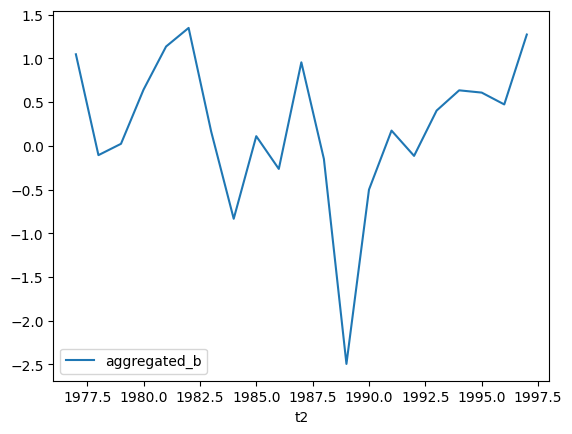

In [101]:
plot(clean(data["lcit2_wt2"])).plot()

<Axes: xlabel='t2'>

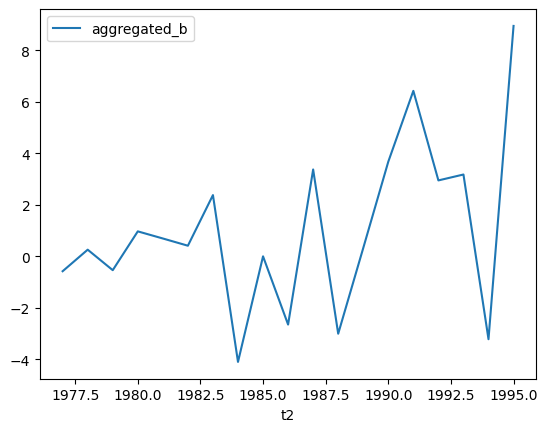

In [102]:
df = clean(data["lcit2_wt2"])
df = df[df['group'] == 1981]
plot(df).plot()